In [14]:
import efinance as ef

df = ef.stock.get_quote_history('TSLA', beg='20210101', end='20260408')


df.rename(columns={'日期':'Date', '开盘':'Open', '最高':'High', '最低':'Low', '收盘':'Close', '成交量':'Volume'}, inplace=True)
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]


print(df.head())
print(df.tail())


         Date     Open     High      Low    Close    Volume
0  2021-01-04  239.820  248.163  239.063  243.257  48638189
1  2021-01-05  241.220  246.947  239.733  245.037  32245165
2  2021-01-06  252.830  258.000  249.700  251.993  44699965
3  2021-01-07  259.210  272.330  258.400  272.013  51498948
4  2021-01-08  285.333  294.830  279.463  293.340  75055528
            Date     Open    High     Low   Close    Volume
1315  2026-03-31  361.510  373.33  361.00  371.75  75534934
1316  2026-04-01  378.630  383.14  374.08  381.26  58683752
1317  2026-04-02  364.195  370.28  359.03  360.59  83031226
1318  2026-04-06  362.590  367.72  346.64  352.82  77697643
1319  2026-04-07  346.440  348.02  337.24  346.65  74515355


I used the 'efinance'library to fetch Tesla's (TSLA) historical stock data.I retrieve raw market data including daily opening, closing prices, and trading volume to build my dataset for further exploration.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'Date' in df.columns:
  df['Date'] = pd.to_datetime(df['Date'])
  df.set_index('Date', inplace=True)

cols = ['Open', 'High', 'Low', 'Close', 'Volume']
df[cols] = df[cols].astype(float)

After renaming the columns, I need to make sure the computer treats the data correctly. I converted the 'Date' column into a proper date format and set it as the index, which makes plotting a lot easier. I also converted the price columns (like Open, High, and Close) into float numbers to ensure I can perform mathematical calculations and avoid any "text-based" data errors.

In [16]:
missing_count = df.isnull().sum()
print(missing_count)


Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


I ensure that there are no missing data.

In this step,I check if there are any missing data and the result is there are no missing data.

In [17]:
df['Daily_Return'] = df['Close'].pct_change()
daily_returns_list = df['Daily_Return'].dropna()

print(daily_returns_list)



Date
2021-01-05    0.007317
2021-01-06    0.028388
2021-01-07    0.079447
2021-01-08    0.078404
2021-01-11   -0.078213
                ...   
2026-03-31    0.046358
2026-04-01    0.025582
2026-04-02   -0.054215
2026-04-06   -0.021548
2026-04-07   -0.017488
Name: Daily_Return, Length: 1319, dtype: float64


I calculate the daily rate of return and delete the first row, as there is no previous day's price to calculate the rate of return on the first day.

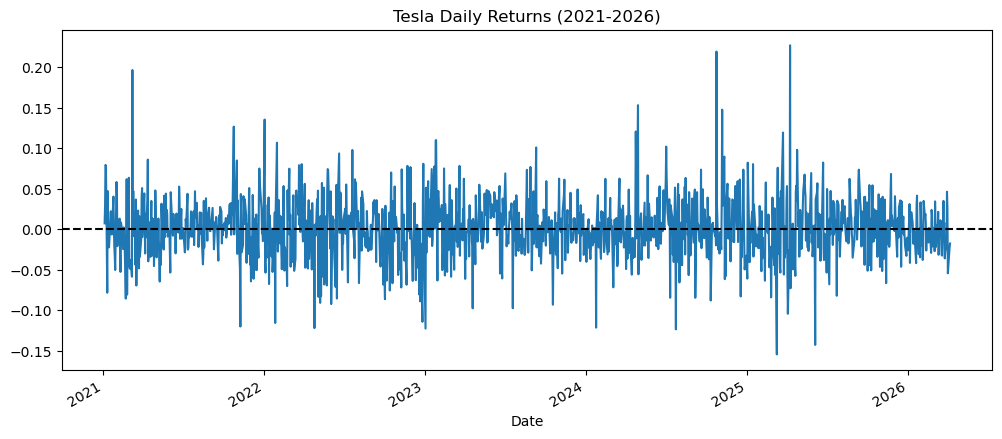

In [18]:
plt.figure(figsize=(12, 5))
daily_returns_list.plot()

plt.title('Tesla Daily Returns (2021-2026)')
plt.axhline(y=0, color='black', linestyle='--')
plt.show()

I draw the daily returns trend according to the data above.

In [23]:
target_date = input("Please enter the date you want to check (e.g., 2024-01-02): ")

try:
    result = daily_returns_list.loc[target_date]
    
    
    print(f"The daily return of Tesla on {target_date} was: {result:.2%}")

except KeyError:
    print(f"Sorry, no data found for {target_date}.")
    print("Tip: Please ensure the date is in YYYY-MM-DD format and it was a trading day.")

except Exception as e:
    print(f"An error occurred: {e}")


The daily return of Tesla on 2023-03-03 was: 3.61%


If the investor want to see the daily return of any target date,she or he can do it.Additionally,if the stock market is closed on the input date, the program will notify the user.
Meanwhile,I convert the result into percentage form for simplicity.This is really helpful for beginner investors.

In [20]:
max_return_date = daily_returns_list.idxmax()
max_return_value = daily_returns_list.max()


min_return_date = daily_returns_list.idxmin()
min_return_value = daily_returns_list.min()

print(f"Highest Return: {max_return_value:.2%} on {max_return_date.date()}")
print(f"Lowest Return: {min_return_value:.2%} on {min_return_date.date()}")


Highest Return: 22.69% on 2025-04-09
Lowest Return: -15.43% on 2025-03-10


This code facilitates the identification of historical maximum and minimum daily returns for entry-level investors.

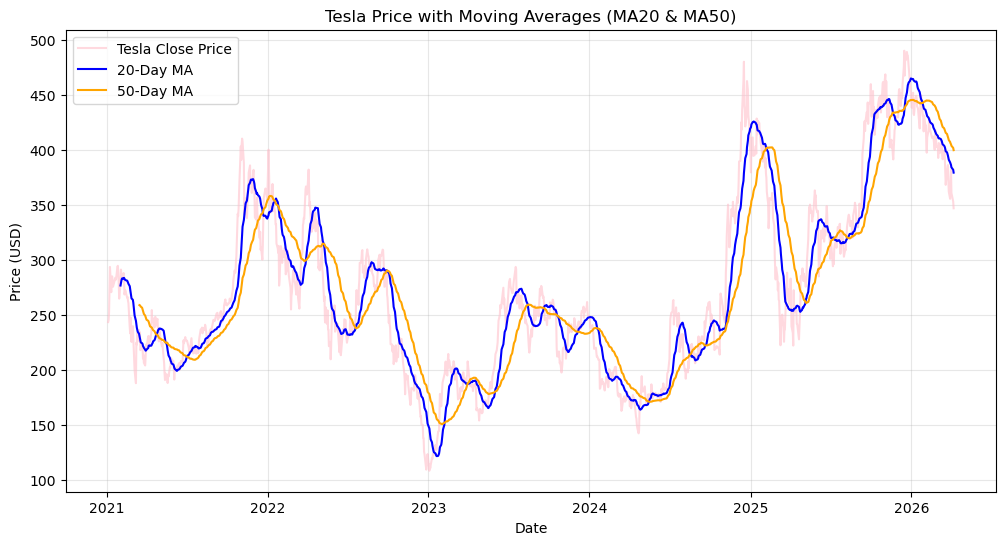

In [21]:
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

plt.figure(figsize=(12, 6))

plt.plot(df.index, df['Close'], label='Tesla Close Price', color='pink', alpha=0.6)
plt.plot(df.index, df['MA20'], label='20-Day MA', color='blue', linewidth=1.5)
plt.plot(df.index, df['MA50'], label='50-Day MA', color='orange', linewidth=1.5)


plt.title('Tesla Price with Moving Averages (MA20 & MA50)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend() 
plt.grid(True, alpha=0.3) 
plt.show()


 I added 20-day and 50-day MAs to better understand Tesla’s momentum. These lines filter out daily market "noise" and show a much clearer trend. This helps beginner investors find potential buy or sell signals more easily than just looking at the messy daily prices.

In [25]:
df.describe()


,Open,High,Low,Close,Volume,Daily_Return,MA20,MA50
count,1320.000000,1320.000000,1320.000000,1320.000000,1.320000e+03,1319.000000,1301.000000,1271.000000
mean,272.780023,278.694477,266.530119,272.615797,8.055258e+07,0.000973,271.912068,270.436673
std,81.786965,83.140552,80.054823,81.573969,4.934209e+07,0.037678,79.604693,75.792039
min,103.000000,111.750000,101.810000,108.100000,9.800558e+06,-0.154262,121.334000,150.403800
25%,214.758750,219.086750,209.172250,214.390000,3.362401e+07,-0.020342,217.293250,217.622860
50%,252.073000,258.243500,246.361500,252.340000,7.658356e+07,0.001034,251.394600,251.226200
75%,327.577500,335.215000,319.867500,328.372250,1.115698e+08,0.020953,323.322500,319.316850
max,489.880000,498.830000,485.330000,489.880000,3.065906e+08,0.226900,464.700500,445.266000


This descriptive statistics table reveals that Tesla (TSLA) is a highly volatile asset. While the average daily return is near zero (0.09%), the standard deviation and the gap between the min (-15%) and max (22%) daily returns highlight significant market risks. Additionally, the mean closing price of around $272 provides a baseline for evaluating whether the current market price is historically high or low.